# Task 1: Exploratory Data Analysis (EDA)

In this task, we analyze the financial news dataset to understand publication trends, headline characteristics, and publisher activity.

In [12]:
# 1. 🛠️ Setup & Installation
%pip install pandas matplotlib seaborn nltk textblob vaderSentiment scikit-learn wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# 2. 📦 Imports & Path Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import os
import sys

# Add project root to path for scripts import
sys.path.append('..')
from scripts.eda_utils import get_top_ngrams, plot_publication_trends, plot_hour_distribution, clean_text

# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Download NLTK data
nltk.download(['punkt', 'stopwords', 'punkt_tab'], quiet=True)

print("✅ Setup successful!")

✅ Setup successful!


In [14]:
# 3. 📂 Data Loading
data_path = '../data/raw/raw_analyst_ratings.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/raw_analyst_ratings.csv'

df = pd.read_csv(data_path)

# Preprocessing dates immediately
df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date'])

print(f"✅ Dataset loaded! Rows: {df.shape[0]}")
df.head()

✅ Dataset loaded! Rows: 55987


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


## 1. Descriptive Statistics & Publisher Activity

Headline Length Stats:
count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_len, dtype: float64


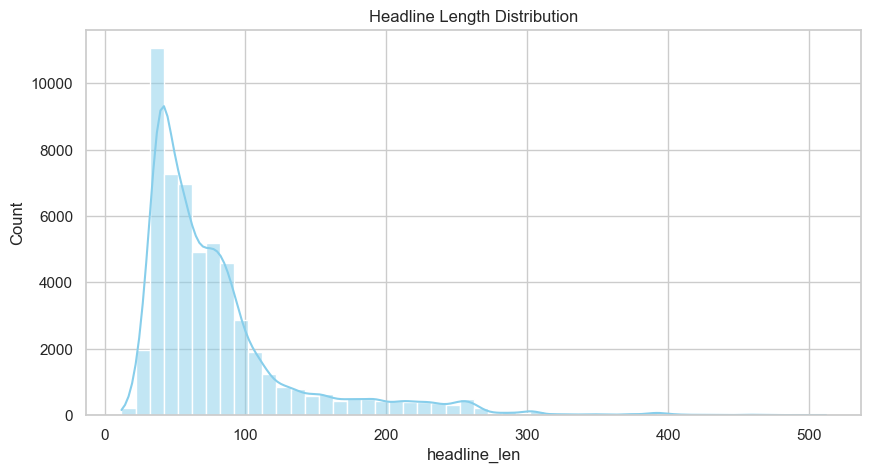

In [15]:
df['headline_len'] = df['headline'].apply(len)
print("Headline Length Stats:")
print(df['headline_len'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['headline_len'], bins=50, kde=True, color='skyblue')
plt.title('Headline Length Distribution')
plt.show()

Top 20 Most Active Publishers:
publisher
Benzinga Newsdesk          14750
Lisa Levin                 12408
ETF Professor               4362
Paul Quintaro               4212
Benzinga Newsdesk           3177
Benzinga Insights           2332
Vick Meyer                  2128
Charles Gross               1790
Hal Lindon                  1470
Benzinga_Newsdesk           1239
Eddie Staley                1003
vishwanath@benzinga.com      924
Shanthi Rexaline             887
Monica Gerson                611
Wayne Duggan                 465
Nelson Hem                   345
Jayson Derrick               337
Craig Jones                  310
luke@benzinga.com            271
Javier Hasse                 250
Name: count, dtype: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_9652\4187424815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='magma')


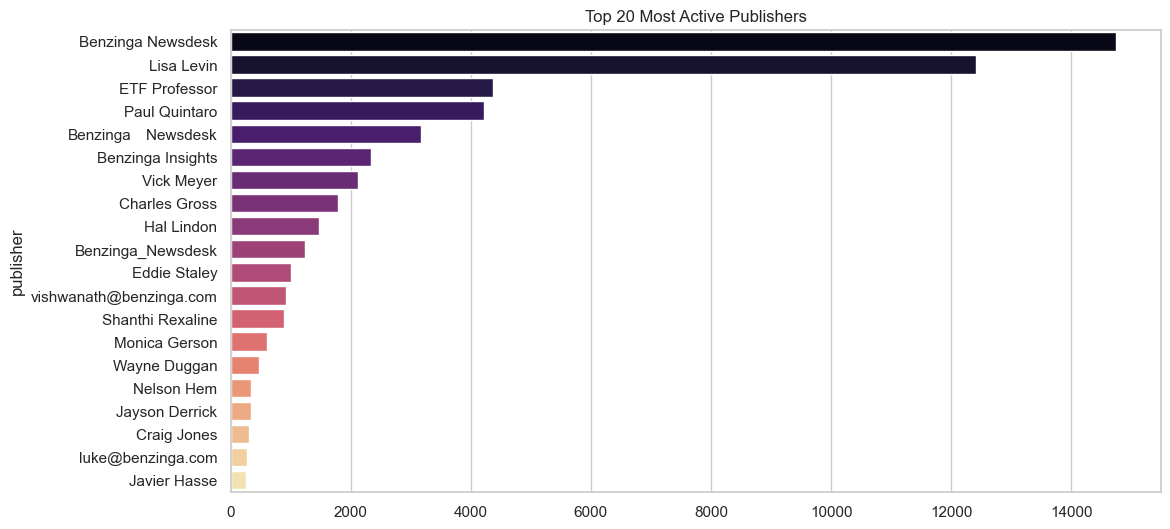

In [16]:
# Identifying most active publishers
publisher_counts = df['publisher'].value_counts().head(20)
print("Top 20 Most Active Publishers:")
print(publisher_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='magma')
plt.title('Top 20 Most Active Publishers')
plt.show()

## 2. Time Series Analysis & Spike Detection

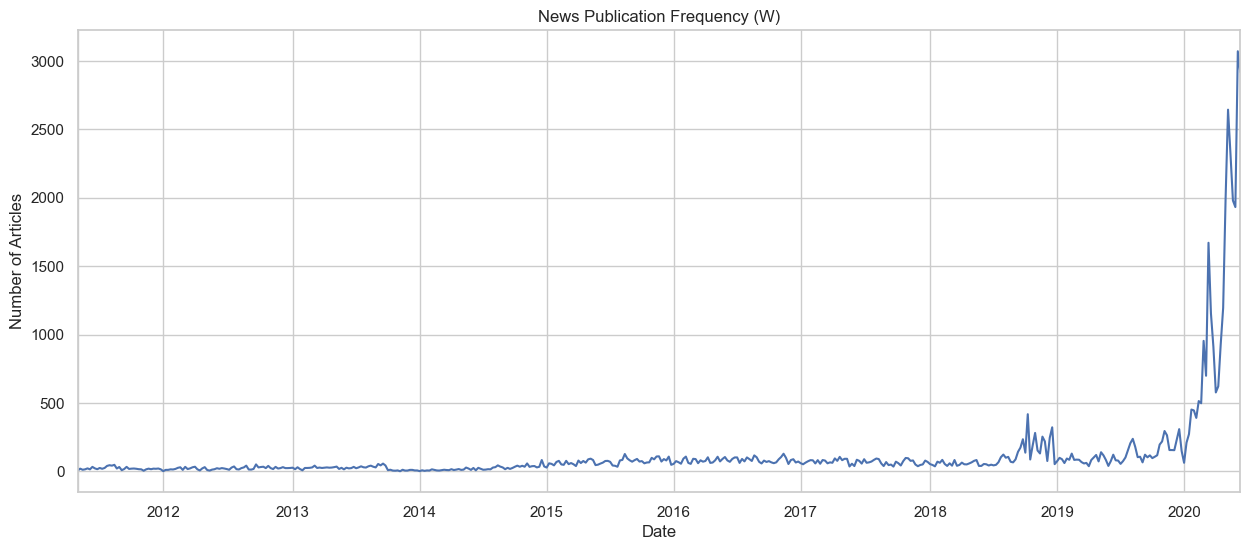

In [17]:
# Overall weekly trend
plot_publication_trends(df, freq='W')

Top 10 News Spikes (Potential Market Events):
date
2020-03-12 00:00:00+00:00    973
2020-06-05 00:00:00+00:00    932
2020-06-10 00:00:00+00:00    807
2020-06-09 00:00:00+00:00    803
2020-06-08 00:00:00+00:00    765
2020-05-07 00:00:00+00:00    751
2020-06-03 00:00:00+00:00    720
2020-03-19 00:00:00+00:00    630
2020-05-26 00:00:00+00:00    628
2020-05-13 00:00:00+00:00    549
dtype: int64


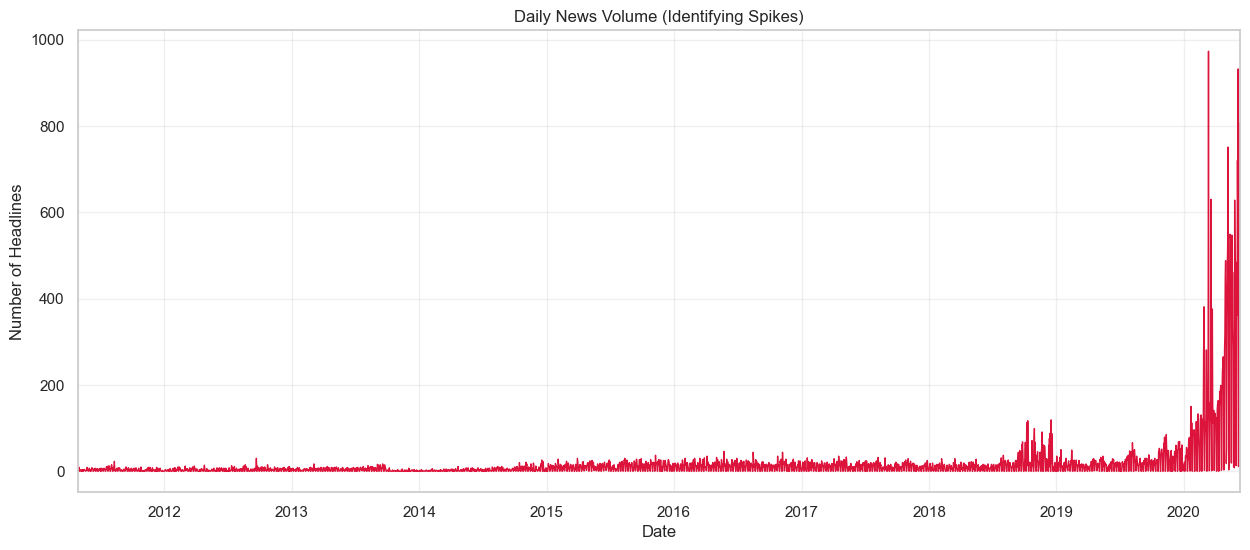

In [18]:
# Granular Daily Trend & Spike Detection
daily_counts = df.set_index('date').resample('D').size()
top_spikes = daily_counts.sort_values(ascending=False).head(10)

print("Top 10 News Spikes (Potential Market Events):")
print(top_spikes)

plt.figure(figsize=(15, 6))
daily_counts.plot(color='crimson', linewidth=1)
plt.title('Daily News Volume (Identifying Spikes)')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.grid(True, alpha=0.3)
plt.show()

c:\Users\acer\Downloads\10 Acadamy\projects\Week_1\scripts\eda_utils.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


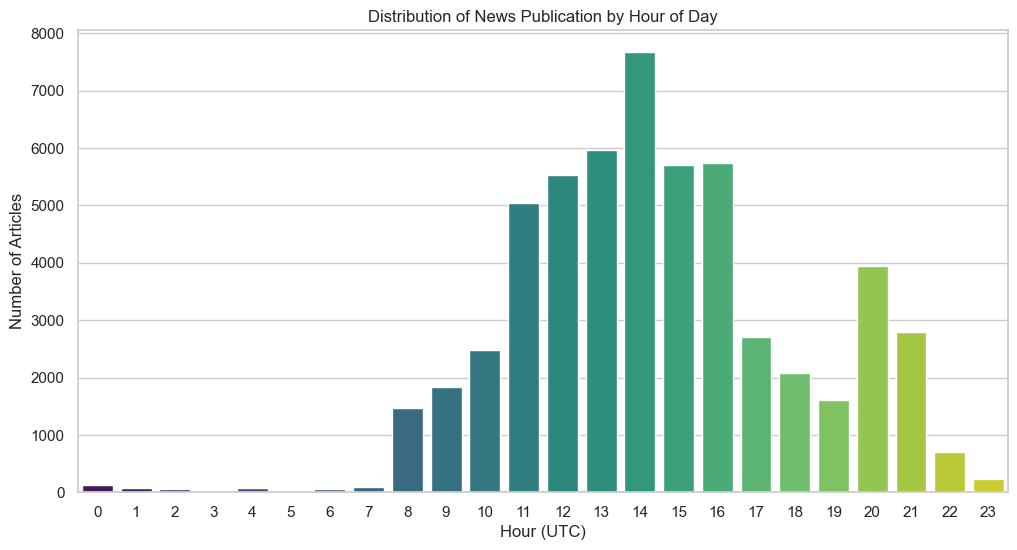

In [19]:
plot_hour_distribution(df)

## 3. Text Analysis (Sentiment & Keywords)

In [20]:
df['clean_headline'] = df['headline'].apply(clean_text)
corpus = df['clean_headline'].tolist()

In [21]:
print("Top Bigrams:", get_top_ngrams(corpus, n=2, n_top=10))
print("Top Trigrams:", get_top_ngrams(corpus, n=3, n_top=10))

Top Bigrams: [('stocks hit', np.int64(5847)), ('hit week', np.int64(5846)), ('price target', np.int64(4585)), ('companies trading', np.int64(4082)), ('week lows', np.int64(3687)), ('trading higher', np.int64(3518)), ('stocks moving', np.int64(2841)), ('week highs', np.int64(2560)), ('trading lower', np.int64(2152)), ('new week', np.int64(2094))]
Top Trigrams: [('stocks hit week', np.int64(5846)), ('hit week lows', np.int64(3531)), ('companies trading higher', np.int64(2557)), ('hit week highs', np.int64(2315)), ('stocks set new', np.int64(2057)), ('set new week', np.int64(2057)), ('raises price target', np.int64(1912)), ('lowers price target', np.int64(1769)), ('week lows thursday', np.int64(1764)), ('new week low', np.int64(1735))]


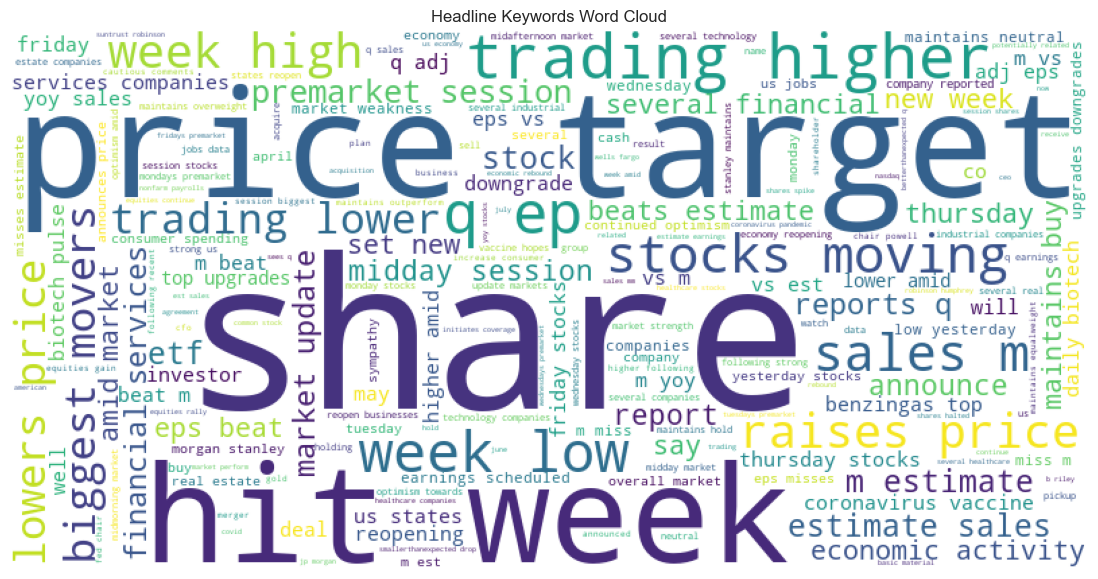

In [22]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(corpus[:5000]))
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Headline Keywords Word Cloud')
plt.show()

## 4. Publisher Domain Analysis

C:\Users\acer\AppData\Local\Temp\ipykernel_9652\3828055123.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_domains.values, y=top_domains.index, palette='viridis')


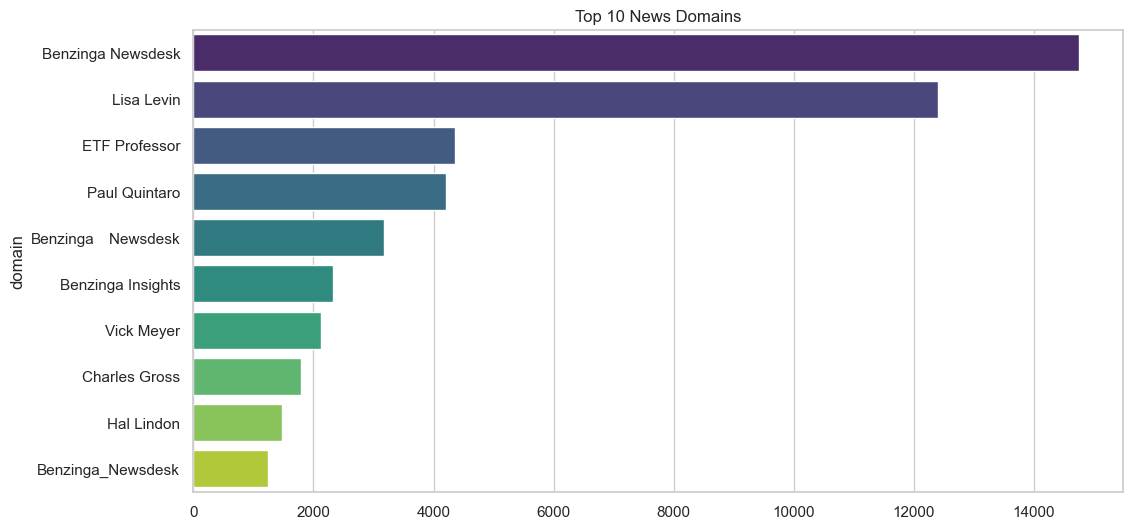

In [23]:
df['domain'] = df['publisher'].apply(lambda x: x.split('@')[-1] if '@' in str(x) else x)
top_domains = df['domain'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_domains.values, y=top_domains.index, palette='viridis')
plt.title('Top 10 News Domains')
plt.show()